#### Section1: Introduction
2. who is this course for?
   - Data engineer
   - Data Platform Owner
   - Data Lead
   - Data Architect

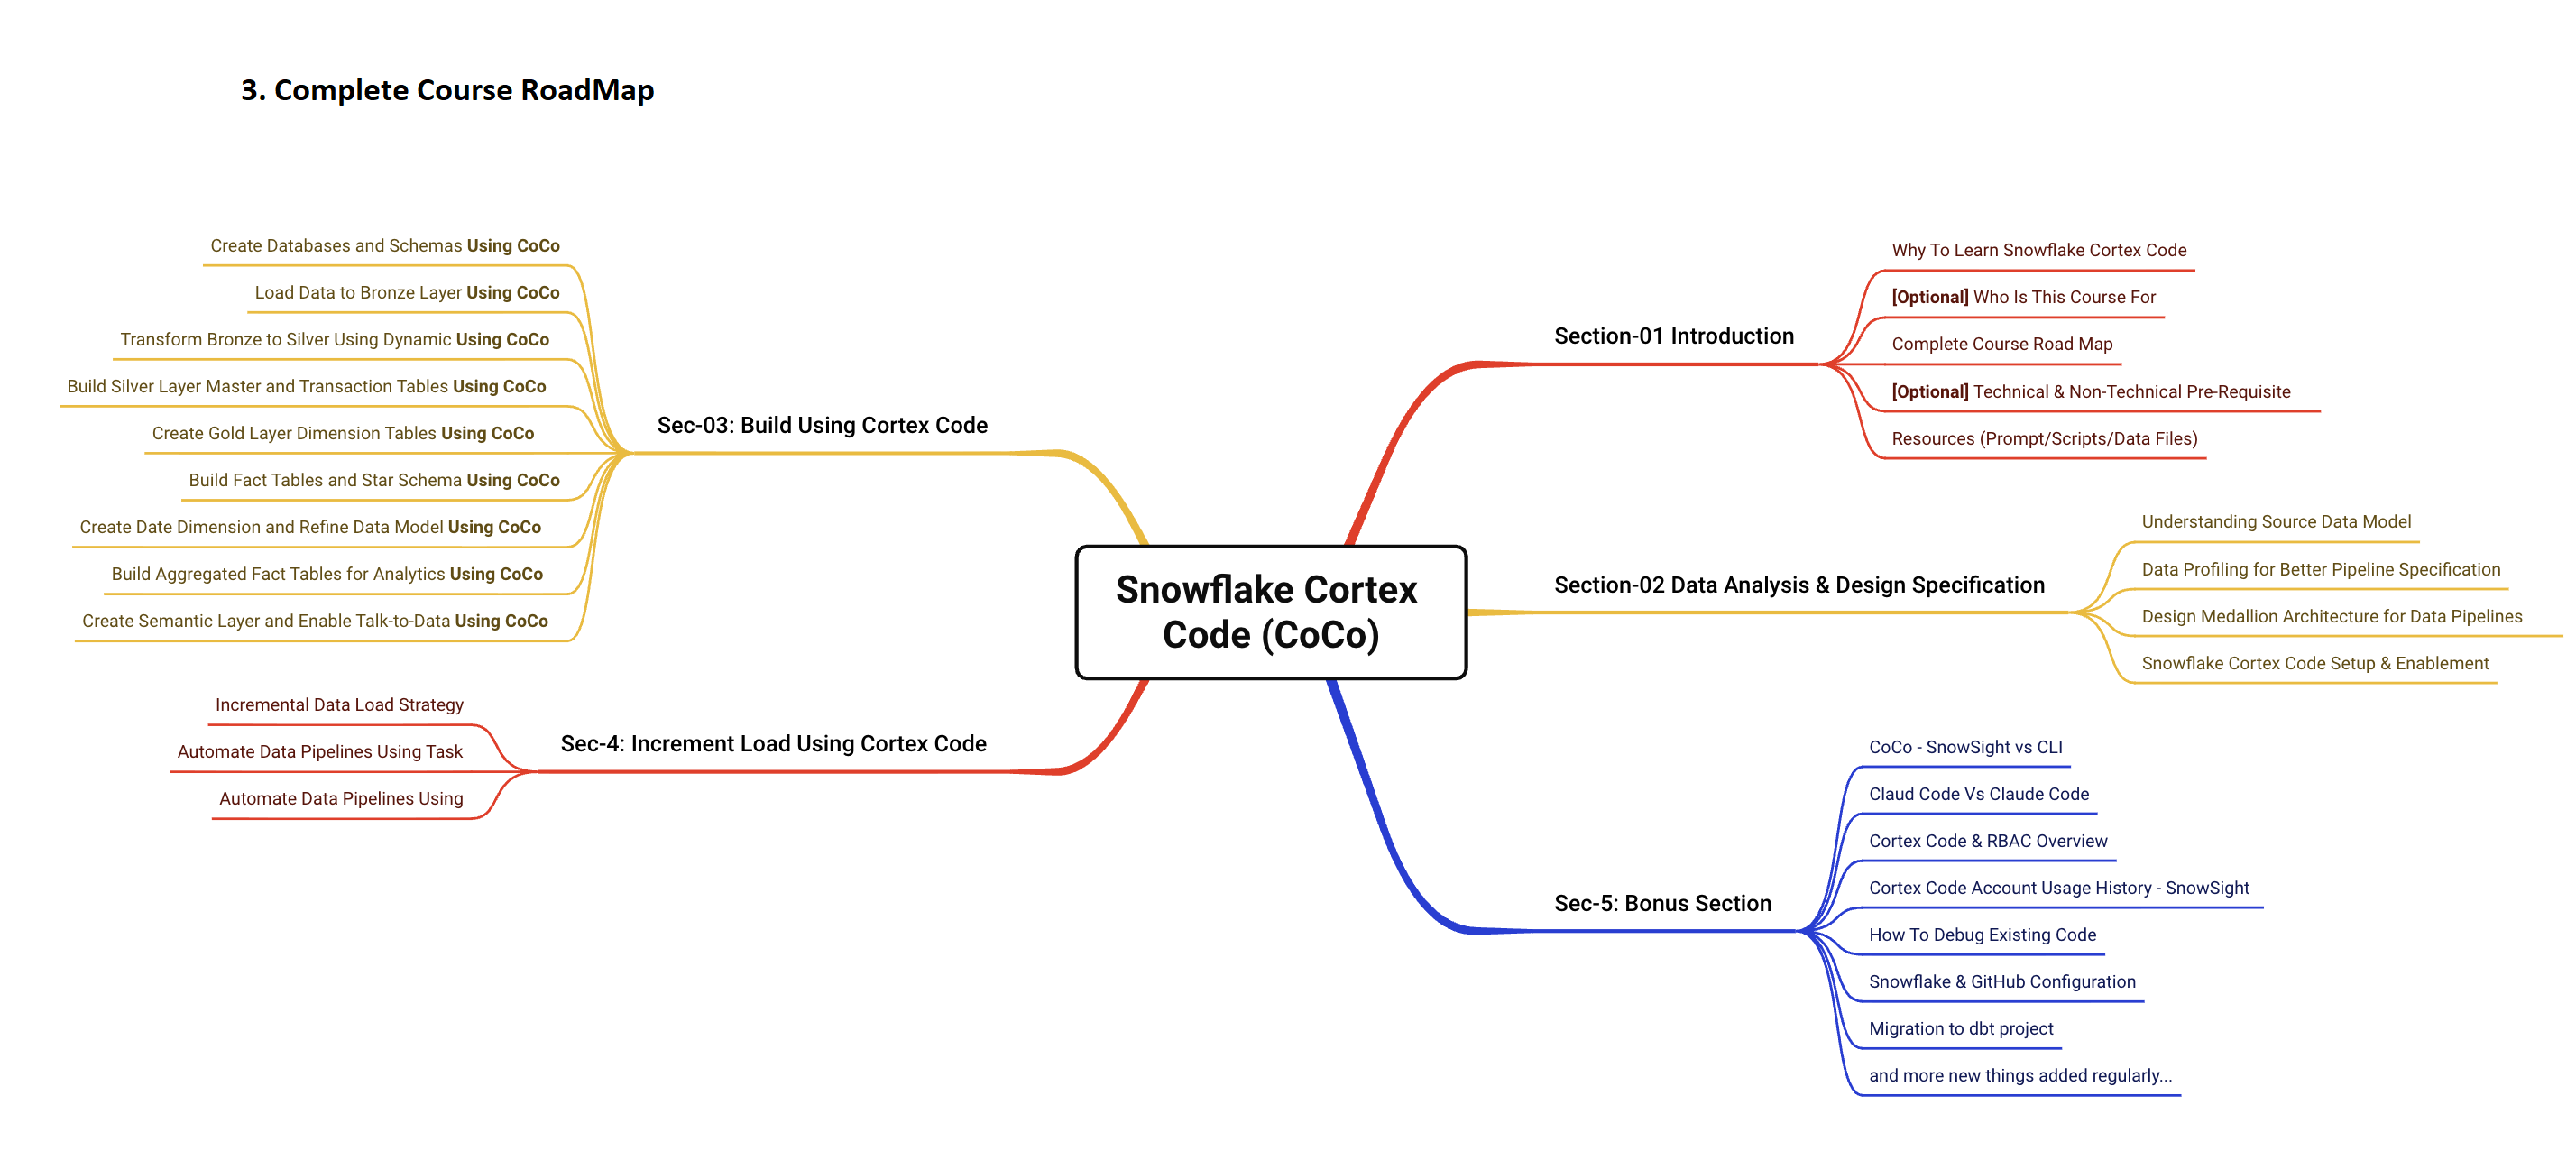

In [4]:
from IPython.display import Image
Image("./img/sfcc1.png")

4. Technical & Non-Technical Pre-Requisite
    - Snowflake account
    - VS code (review data files, prompt and sql code)
    - SQL Knowledge(DDL/DML)
    - Dynamic tables
    - copy commands
    - Snowsight web UI
    - Dimensional Modeling
    - Medallion Architecture
5.  Resources (Prompt/Scripts/Data Files)
    - Zip files of all resources

#### Section 2: Design Phase: Data Profiling, Medallion Architecture & Cortex Code Enablement

"Apple's supply chain has been ranked #1 in the world by Gartner for over a decade — because behind every iPhone sold is a massive web of data: store data, customers data, products data & sales transactions data — all connected.Today, we're going to build exactly that kind of pipeline"

6. Understanding the Apple-Inspired Product Sales Data Model.
    - What You Will LearnUnderstand the 13-table Apple-like product sales data model.
    - Recognize the data domains: geography/currency, product hierarchy, store, customer and transactional.
    - See how normalized source data maps to a future star schema (dimensional modelling).
    - Understand why data source clarity is the first step in any pipeline specification.

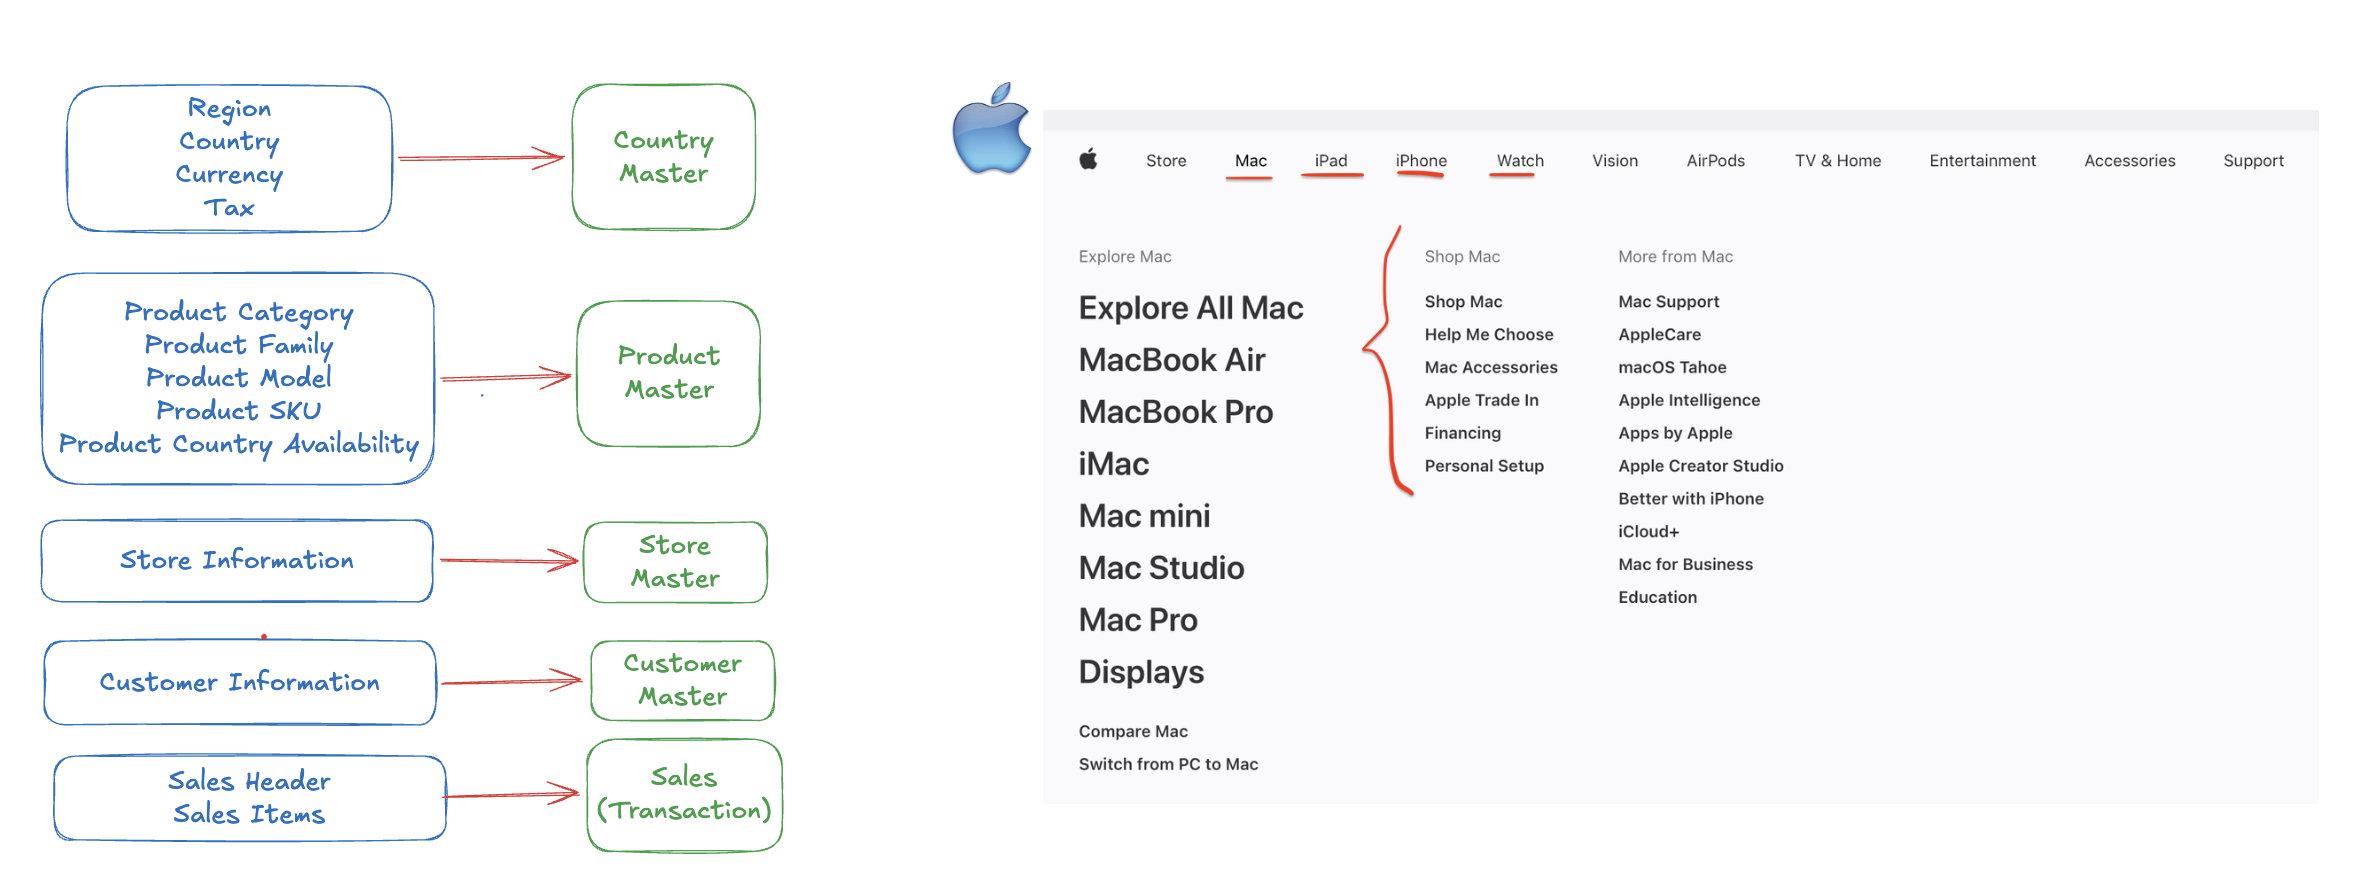

In [6]:
from IPython.display import Image
Image("./img/sfcc3.png")

7. Data Profiling: Row Counts, Columns and Source Systems Walkthrough

"Apple processes over 2 billion active devices generating data every single second. But even at that scale, every data pipeline starts the same way — with someone asking:what does this data actually look like?That’s data profiling. And that’s exactly what we’re doing right now."

In [21]:
import pandas as pd
df1 = pd.read_csv('E:\\code\\4.Database\\data\\country_master.csv')
df1.head()

,country_code,country_name,region_code,currency_code,tax_code,primary_language,timezone,ecommerce_supported,retail_store_supported,market_tier,population_millions,gdp_usd_billions,is_active,effective_start_date,effective_end_date,created_at,source_system
0,US,United States,AMER,USD,US_STD,English,America/New_York,Y,N,Tier2,709,17774,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.217571,MDM_CORE
1,UK,United Kingdom,EMEA,GBP,UK_VAT_STD,English,Europe/London,Y,N,Tier2,685,16943,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.217580,MDM_CORE
2,JP,Japan,JAPAN,JPY,JP_VAT_STD,Japanese,Asia/Tokyo,Y,Y,Tier2,599,25103,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.217583,MDM_CORE
3,CN,China,APAC,CNY,CN_VAT_STD,Chinese,Asia/Shanghai,Y,Y,Tier2,450,17146,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.217586,MDM_CORE
4,IN,India,APAC,INR,IN_GST_STD,Hindi,Asia/Kolkata,Y,Y,Tier2,1042,8067,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.217588,MDM_CORE


In [22]:
df2 = pd.read_csv('E:\\code\\4.Database\\data\\currency_master.csv')
df2.head()

,currency_code,currency_name,currency_symbol,minor_unit,is_active,effective_start_date,effective_end_date,created_at,source_system
0,USD,US Dollar,$,2,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.213269,TREASURY_SYS
1,GBP,British Pound,£,2,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.213272,TREASURY_SYS
2,JPY,Japanese Yen,¥,0,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.213276,TREASURY_SYS
3,CNY,Chinese Yuan,¥,2,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.213276,TREASURY_SYS
4,INR,Indian Rupee,₹,2,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.213277,TREASURY_SYS


In [23]:
df3 = pd.read_csv('E:\\code\\4.Database\\data\\region_master.csv')
df3.head()

,region_code,region_name,is_active,effective_start_date,effective_end_date,created_at,source_system
0,AMER,Americas,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.209255,MDM_CORE
1,EMEA,Europe Middle East Africa,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.209258,MDM_CORE
2,JAPAN,Japan,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.209259,MDM_CORE
3,APAC,Asia Pacific,Y,2000-01-01,9999-12-31,2026-02-05 18:17:58.209260,MDM_CORE


In [24]:
df4 = pd.read_csv('E:\\code\\4.Database\\data\\tax_master.csv')
df4.head()

,tax_code,tax_type,tax_rate,tax_inclusive_flag,effective_start_date,effective_end_date,is_active,created_at,source_system
0,US_STD,SALES_TAX,0.07,N,2020-01-01,9999-12-31,Y,2026-02-05 18:17:58.216237,TAX_ENGINE
1,UK_VAT_STD,VAT,0.20,Y,2020-01-01,9999-12-31,Y,2026-02-05 18:17:58.216239,TAX_ENGINE
2,JP_VAT_STD,VAT,0.10,Y,2020-01-01,9999-12-31,Y,2026-02-05 18:17:58.216240,TAX_ENGINE
3,CN_VAT_STD,VAT,0.13,Y,2020-01-01,9999-12-31,Y,2026-02-05 18:17:58.216241,TAX_ENGINE
4,IN_GST_STD,GST,0.18,Y,2020-01-01,9999-12-31,Y,2026-02-05 18:17:58.216241,TAX_ENGINE


In [25]:
df4.T

,0,1,2,3,4
tax_code,US_STD,UK_VAT_STD,JP_VAT_STD,CN_VAT_STD,IN_GST_STD
tax_type,SALES_TAX,VAT,VAT,VAT,GST
tax_rate,0.07,0.2,0.1,0.13,0.18
tax_inclusive_flag,N,Y,Y,Y,Y
effective_start_date,2020-01-01,2020-01-01,2020-01-01,2020-01-01,2020-01-01
effective_end_date,9999-12-31,9999-12-31,9999-12-31,9999-12-31,9999-12-31
is_active,Y,Y,Y,Y,Y
created_at,2026-02-05 18:17:58.216237,2026-02-05 18:17:58.216239,2026-02-05 18:17:58.216240,2026-02-05 18:17:58.216241,2026-02-05 18:17:58.216241
source_system,TAX_ENGINE,TAX_ENGINE,TAX_ENGINE,TAX_ENGINE,TAX_ENGINE


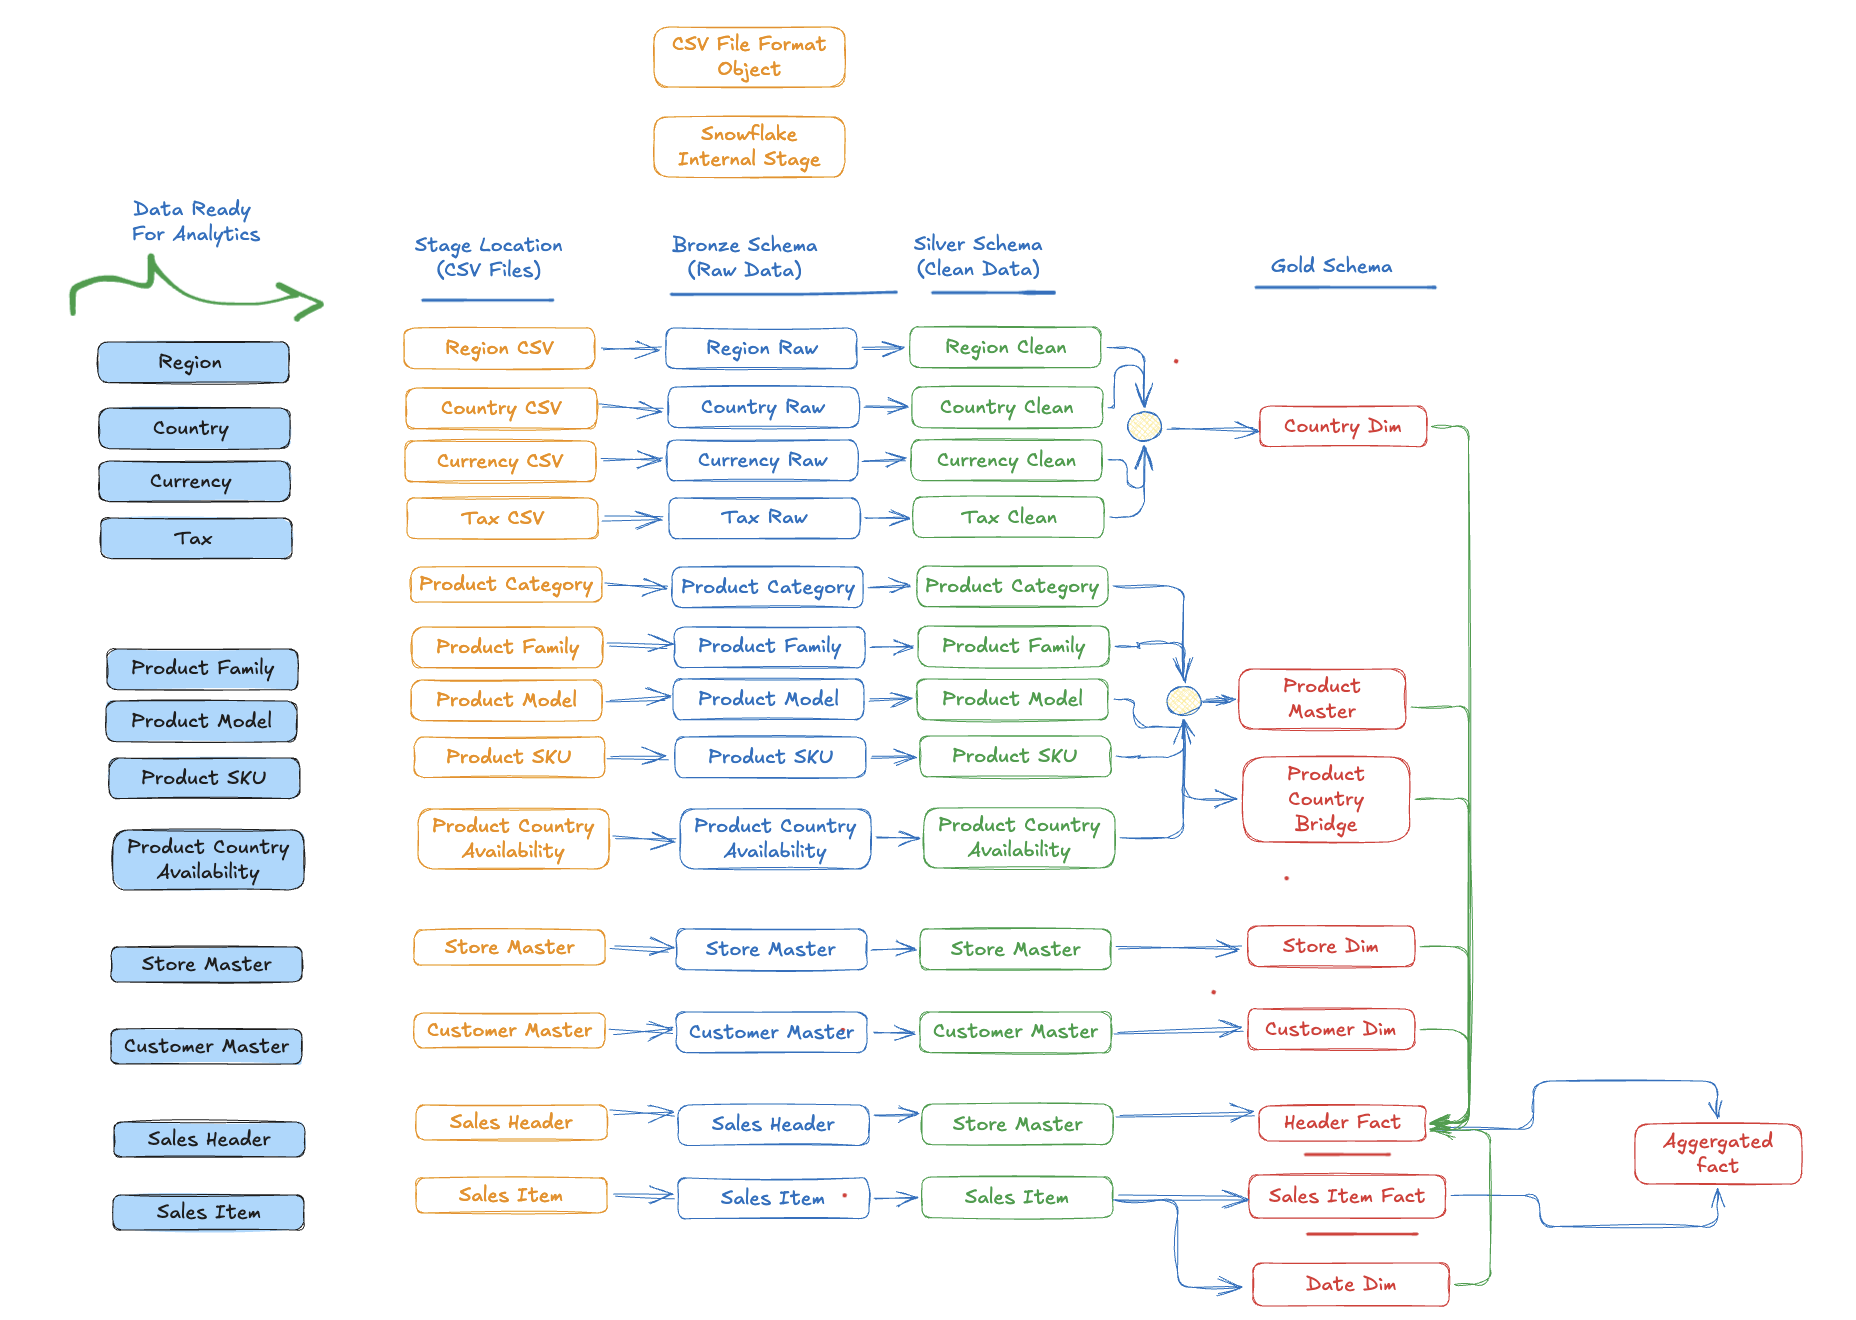

In [1]:
from IPython.display import Image
Image("./img/sfcc2.png")

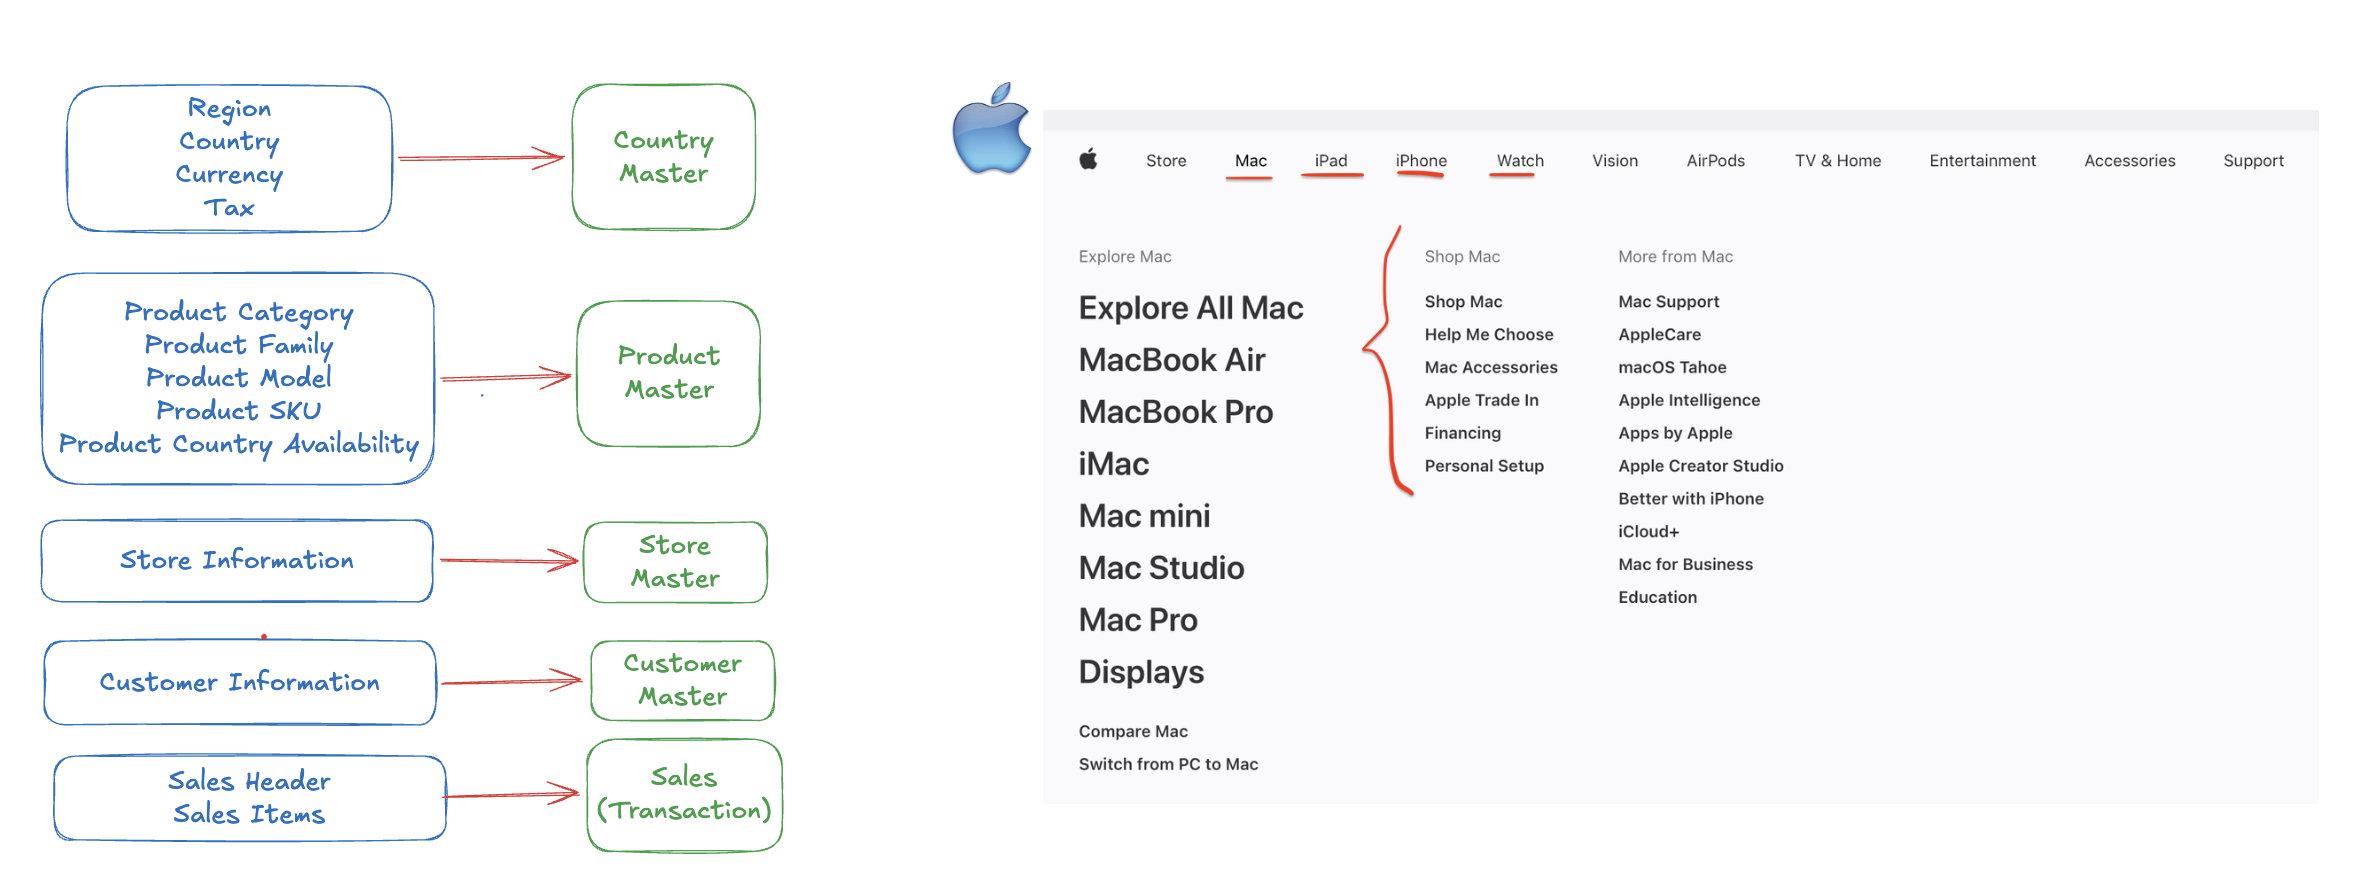

In [ ]:
- 
- 8. Medallion Architecture: Designing the End-to-End Pipeline Blueprint
- 9. Cortex Code First Look: Enable, Navigate and Validate in Snowsight

#### Section 3: Cortex Code in Action: Build End-to-End Data Pipeline Without Writing SQL. 
- 10. Create Databases & Schemas by Feeding Architecture Diagram to Cortex Code
- 11. Upload CSV Files & Load All 13 Tables into Bronze Layer via Cortex Code
- 12. Load Data From Bronze To Silver Layer Using Dynamic Tables
- 13. Build Silver Layer Master and Transaction Tables Using Cortex Code
- 14. Store, Customer & Sales Data Movement From Bronze2Silver Using Cortex Code14. Store, Customer & Sales Data Movement From Bronze2Silver Using Cortex Code
- 15. Build Fact Tables & Star Schema in Gold Layer Using Cortex Code
- 16. Build Store, Customer Dim & Sales Fact In Gole Layer Using Cortex Code
- 17. Create Date Dimension and Refine Data Model Using Cortex Code
- 18. Build Aggregated Fact Tables for Analytics Using Cortex Code
- 19. Create Semantic Layer and Enable Talk-to-Data Using Cortex Code

#### Section 4: Incremental Data Processing and Pipeline Automation with Cortex Code
- 20. Incremental Data Load Strategy Using Snowflake Cortex Code.
- 21. Automating Data Pipelines with Tasks Using Snowflake Cortex Code
- 22. End-to-End Incremental Data Load Demo Using Cortex Code

#### Section 5: [Optional] Bonus Section
- 23. [Optional] Snowflake Cortex Code Usage and Cost Calculation
- 24. [Optional] GitHub Integration with Snowflake Workspace Using Cortex Code.
- 25. [Optional] Snowflake Cortex Code on GCP: Setup and Latency Challenges
- 26. [Optional] Data Pipeline Migration To dbt Core Using Snowflake Cortex Code